In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# Import the framework
from nowcasting_framework import (
    NowcastConfig,
    DataManager,
    ModelManager,
    EvaluationManager,
    VisualizationManager,
    InferencePipeline
)

# Import model
from sklearn.linear_model import Ridge

## 1. Configuration

In [2]:
# Configure Ridge experiment
config = NowcastConfig(
    target_variable="gdpc1",
    test_start_date="2005-03-01",
    test_end_date="2010-03-01",
    n_lags=4,
    n_ensemble_models=1,  # Deterministic model, no ensemble needed
    quarterly_only=True
)

print("Ridge Regression Configuration:")
print("=" * 60)
for key, value in config.to_dict().items():
    print(f"{key:20s}: {value}")
print("=" * 60)

Ridge Regression Configuration:
target              : gdpc1
test_period         : 2005-03-01 to 2010-03-01
lags                : [-2, -1, 0, 1, 2]
n_lags              : 4
n_ensemble          : 1


## 2. Data Loading

In [3]:
# Initialize and load data
data_manager = DataManager(config)
data_manager.load_data().prepare_test_data()

# Display data summary
data_manager.summary()

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods


,Metric,Value
0,Total Observations,913
1,Test Periods,21
2,Variables,24
3,Target Variable,gdpc1
4,Missing in Target (%),66.9%


## 3. Model Training and Backtesting

In [4]:
# Configure Ridge parameters
ridge_params = {'alpha': 0.1}

# Create model manager and run backtest
ridge_model = ModelManager(Ridge, ridge_params, config)
ridge_model.run_backtest(data_manager)


Running backtest with 1 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed


## 4. Evaluation

In [5]:
# Evaluate model performance
evaluator = EvaluationManager()
evaluator.add_model_results(
    'Ridge (α=0.1)',
    ridge_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Display performance metrics
print("\nPERFORMANCE BY VINTAGE:")
print("-" * 60)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


PERFORMANCE BY VINTAGE:
------------------------------------------------------------


Model,Vintage,Ridge (α=0.1)
0,-2,0.008167
1,-1,0.006155
2,0,0.005311
3,1,0.004966
4,2,0.004729



MODEL EVALUATION SUMMARY

Model: Ridge (α=0.1)
  Average RMSE across vintages: 0.005866
  Best vintage: lag=2 (RMSE=0.004729)



## 5. Visualization

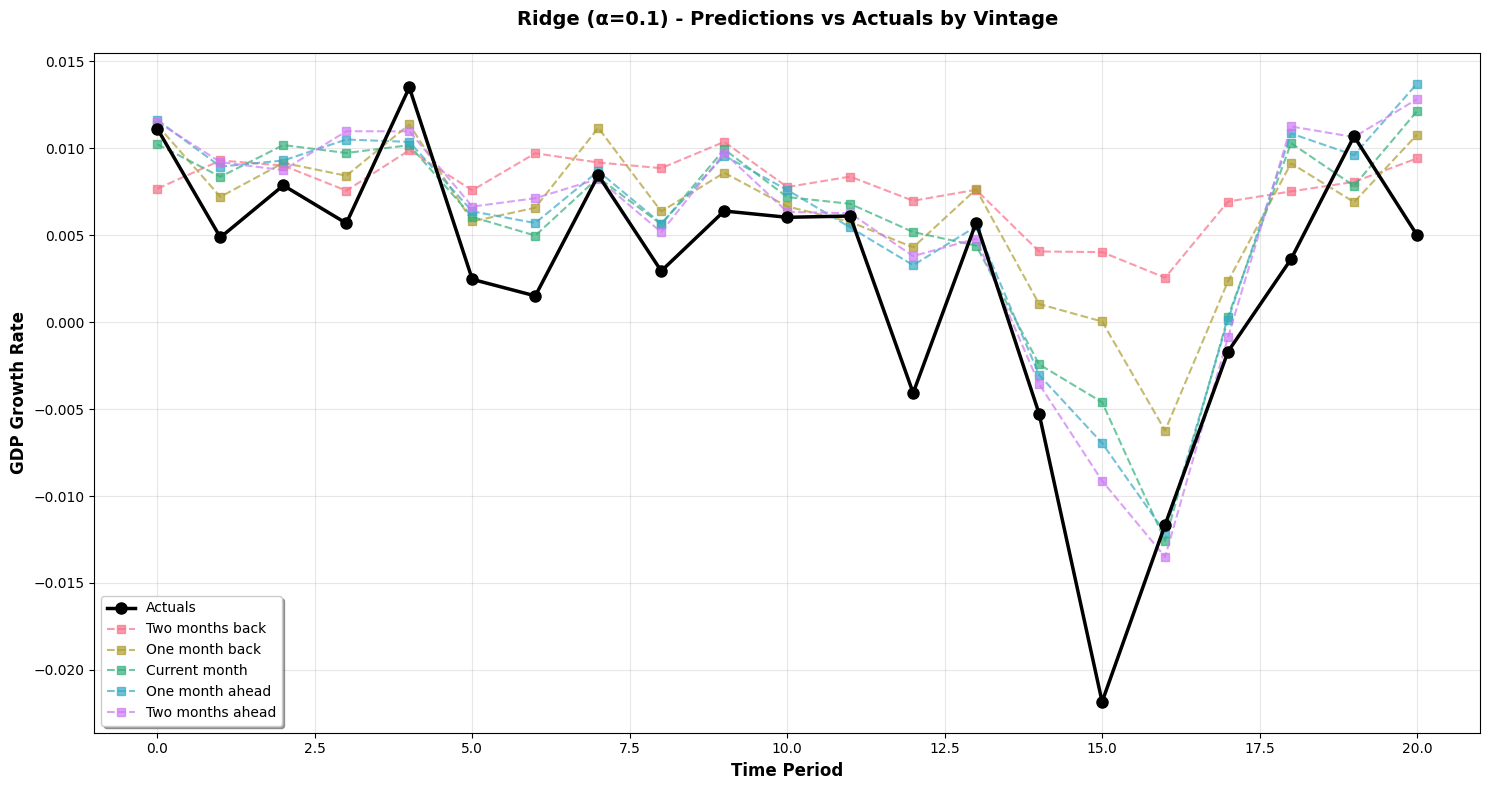

In [6]:
# Create visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions vs actuals
fig1 = viz.plot_predictions_vs_actuals('Ridge (α=0.1)')
plt.show()

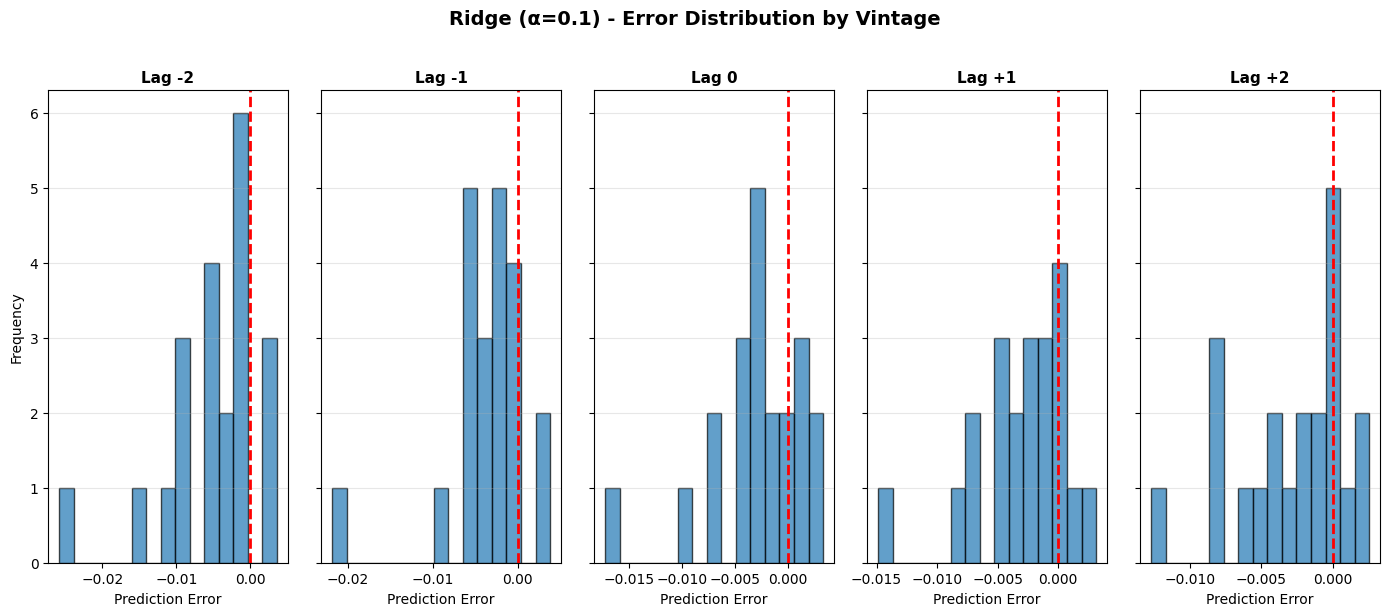

In [7]:
# Plot error distribution
fig2 = viz.plot_error_distribution('Ridge (α=0.1)')
plt.show()

## 6. Production Inference

In [8]:
# Create inference pipeline
inference = InferencePipeline(ridge_model, data_manager, config)

# Predict future quarter
prediction = inference.predict_new_date("2010-06-01")

print("\nFUTURE PREDICTION:")
print("=" * 60)
for key, value in prediction.items():
    print(f"{key:20s}: {value}")


FUTURE PREDICTION:
target_date         : 2010-06-01
prediction          : 0.007807857944336446
target_variable     : gdpc1
n_models            : 1
model_class         : Ridge


## Summary

This notebook implements Ridge regression for GDP nowcasting. Ridge regression adds an L2 penalty to ordinary least squares, which helps prevent overfitting when there are many predictors. With `alpha=0.1`, we apply moderate regularization that shrinks coefficients without eliminating them entirely.

Ridge is deterministic, so unlike tree-based methods, we don't need to average multiple models. The framework approach makes it straightforward to experiment with different alpha values and compare performance across data vintages.